<a href="https://colab.research.google.com/github/anuragN2107/Anurag_Srivastva/blob/main/Telecom_Customer_Churn_Predictor_(Logistic_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project: Telecom Customer Churn Predictor (Logistic Regression)

# 1. Business Problem
Acquiring new customers costs 5 to 25 times more than retaining existing ones. In the hyper-competitive telecom industry, customer acquisition costs (CAC) are high. If a subscriber leaves, the company loses future recurring revenue and the money spent to acquire them.

# 2. Objective
To build a predictive machine learning model that calculates the probability of a customer churning. This allows the marketing and retention teams to proactively target high-risk customers with specialized incentives (e.g., discounts, free upgrades) before they cancel their service.

# 3. Methodology
We will use Logistic Regression, a fundamental and highly interpretable classification algorithm. Unlike Linear Regression which predicts continuous values, Logistic Regression uses the sigmoid function to map any real-valued number into a probability between 0 and 1.$$P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + ... + \beta_nX_n)}}$$If the probability is $\ge 0.5$, we classify the customer as "Will Churn" (1); otherwise, they "Will Stay" (0).

# 4. Dataset
Dataset: Kaggle's Telco Customer Churn dataset (contains 7,043 rows, featuring demographic data, account information, and services signed up for).

# 5. Tools
Tools: Python, Jupyter Notebook / Google Colab, Pandas (data manipulation), NumPy (math), Scikit-Learn (machine learning), Seaborn & Matplotlib (visualization).

# Step 1: Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
# Load dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
# Display information
print(f"Dataset Shape: {df.shape}")
print(df.info())
df.head()

Dataset Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 2: Data Cleaning & Exploratory Data Analysis (EDA)

Clean the data and find hidden patterns.
* **Type Casting:** Converting strings to numbers if they represent numeric values.
* **Handling Missing Values:** Dropping or imputing blank rows.
* **Class Imbalance:** Checking if the data has a skewed distribution of Churn vs. No Churn.

In [4]:
# 1. Drop irrelevant columns
df.drop('customerID', axis=1, inplace=True)

In [5]:
# 2. Fix TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for newly created null values
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Drop rows with missing TotalCharges
df.dropna(inplace=True)

Missing values in TotalCharges: 11


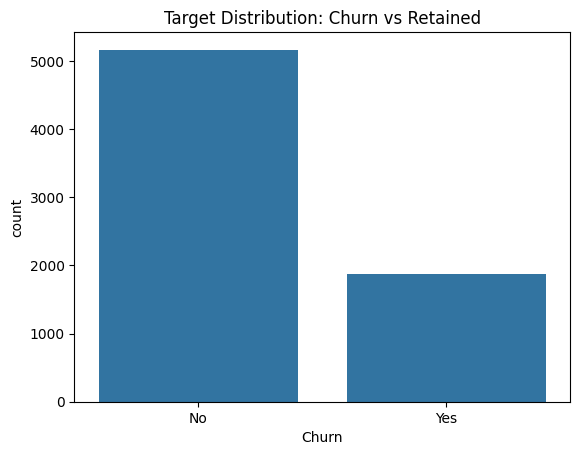

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


In [6]:
# 3. Explore Target Variable Distribution
sns.countplot(x='Churn', data=df)
plt.title('Target Distribution: Churn vs Retained')
plt.show()

print(df['Churn'].value_counts(normalize=True))

# Key Insights from EDA
* Class Imbalance: Roughly 26.5% of the customers in this dataset churned, while 73.5% stayed. This means our baseline accuracy to beat is 73.5%.
* Contract Type matters: Customers on Month-to-month contracts churn at a significantly higher rate than those on 1 or 2-year contracts.



# Step 3 : Feature Engineering
Prepare data so the math behind Logistic Regression can read it.
* **One-Hot Encoding:** Turning categorical strings ("Yes", "No", "DSL") into 0s and 1s.
* **Feature Scaling:** Standardizing numeric features (like `MonthlyCharges`) to have a mean of 0 and variance of 1 so large numbers don't dominate the model.

In [7]:
# Convert target variable to binary numeric format
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [8]:
# Identify numeric and categorical columns
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in df.columns if col not in numeric_features + ['Churn']]

In [9]:
# One-Hot Encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [10]:
# Separate Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric features
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Step 4: Model Training
Train the Logistic Regression model.
* **Model Fitting:** Passing the processed training data to the algorithm to calculate the optimal weights ($\beta$ coefficients).
* **Hyperparameters:** Using parameters like `class_weight='balanced'` to account for data imbalance.

In [11]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


#Step 5: Model Evaluation & Performance Metrics
Evaluate how well the model predicts on completely unseen data.
* **Confusion Matrix:** A grid showing True Positives, False Positives, True Negatives, and False Negatives.
* **Recall:** Out of everyone who *actually* churned, how many did we successfully find? (Crucial for business).
* **ROC-AUC:** Measures how well the model separates the two classes across various probability thresholds.

In [13]:
#predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [15]:
# Evaluation Reports
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- Confusion Matrix ---
[[724 309]
 [ 77 297]]


In [18]:
# Classification Report
print("\n---     Classification Report      ---")
print(classification_report(y_test, y_pred))


---     Classification Report      ---
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [17]:
# Calculate ROC-AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.8353


# 6. Final Insights
Top Churn Predictors: Long-term contracts and high tenure drastically decrease the probability of churn. High monthly charges and month-to-month contracts drastically increase the probability of churn.

Business Impact: By outputting probability scores instead of hard 0s and 1s, the marketing team can rank-order customers. For instance, they can pull a list of the "Top 10% highest-risk customers" every Monday morning and push automated retention discounts to them.


# 7. Future Improvements
Try Advanced Algorithms: Compare this baseline with tree-based models like Random Forests or XGBoost to see if non-linear interactions yield higher recall.

Threshold Tuning: Instead of the default 0.5 probability cutoff, tune the threshold down (e.g., 0.4) to catch even more at-risk customers, balancing the cost of giving away unnecessary discounts against the revenue saved.